In [1]:
# # Install extra libraries
# !pip install wordcloud textblob seaborn nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from textblob import TextBlob

nltk.download('punkt')
nltk.download('stopwords')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (8,5)


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
imdb_train = pd.read_csv('imdb_train.csv')
imdb_test = pd.read_csv('imdb_test.csv')

imdb = pd.concat([imdb_train, imdb_test], ignore_index=True)
imdb.head()


,review,label
0,I really don't understand why people get so up...,1
1,The film transported everyone back to October ...,1
2,"I am a big fan of the movie, but not for the u...",1
3,"First, this is a review of the two disc set th...",1
4,"Even though we know how the story ends, this i...",1


In [ ]:
amazon = pd.read_csv('/content/amazon.csv')  # Change filename if needed
amazon.head()

In [4]:
print("IMDB Info:")
print(imdb.info())

IMDB Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  50000 non-null  object
 1   label   50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB
None


In [ ]:


print("\nAmazon Info:")
print(amazon.info())

Missing Values

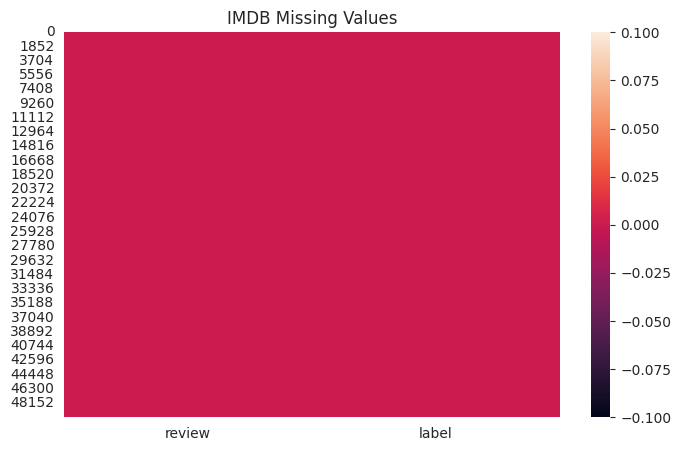

In [7]:
plt.figure()
sns.heatmap(imdb.isnull())
plt.title("IMDB Missing Values")
plt.show()

Length Analysis

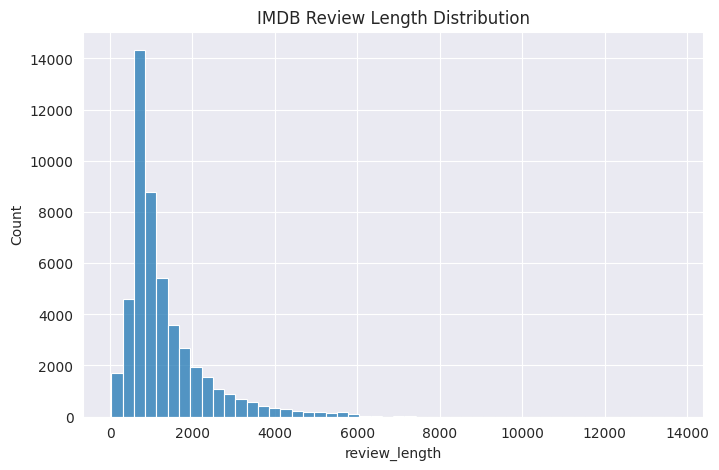

In [10]:
imdb['review_length'] = imdb['review'].apply(lambda x: len(str(x)))

plt.figure()
sns.histplot(imdb['review_length'], bins=50)
plt.title("IMDB Review Length Distribution")
plt.show()

In [14]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Simple split instead of word_tokenize
    tokens = text.split()
    tokens = [word for word in tokens if word not in stop_words]

    return " ".join(tokens)

imdb['cleaned_review'] = imdb['review'].apply(clean_text)

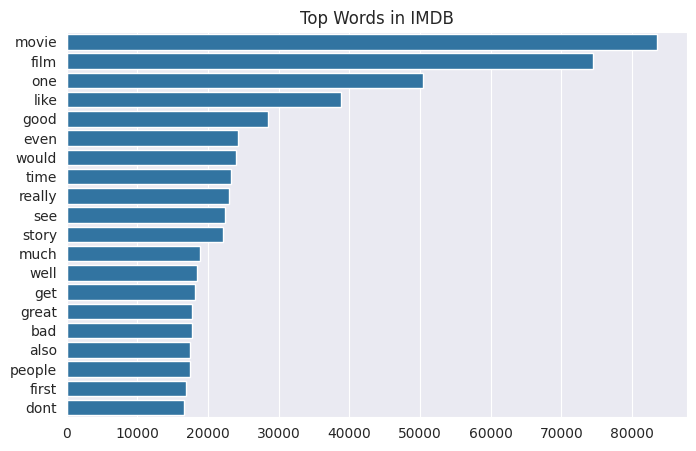

In [16]:
from collections import Counter

def plot_top_words(text_series, title):
    all_words = " ".join(text_series).split()
    word_freq = Counter(all_words)
    common_words = word_freq.most_common(20)

    words = [w[0] for w in common_words]
    counts = [w[1] for w in common_words]

    plt.figure()
    sns.barplot(x=counts, y=words)
    plt.title(title)
    plt.show()

plot_top_words(imdb['cleaned_review'], "Top Words in IMDB")

Generate Word Cloud

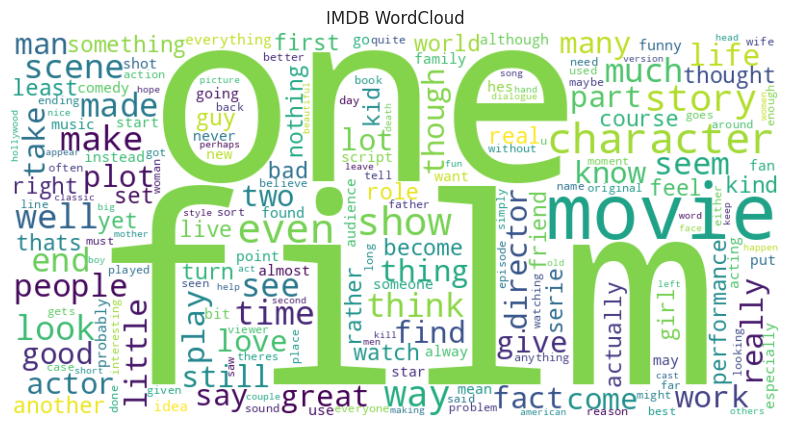

In [17]:
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

generate_wordcloud(" ".join(imdb['cleaned_review']), "IMDB WordCloud")

Sentiment Ploarity Distribution

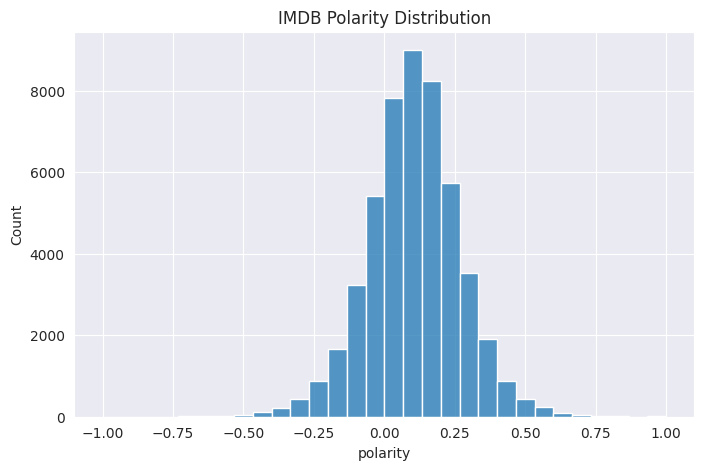

In [18]:
imdb['polarity'] = imdb['review'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

plt.figure()
sns.histplot(imdb['polarity'], bins=30)
plt.title("IMDB Polarity Distribution")
plt.show()

Correlation Map

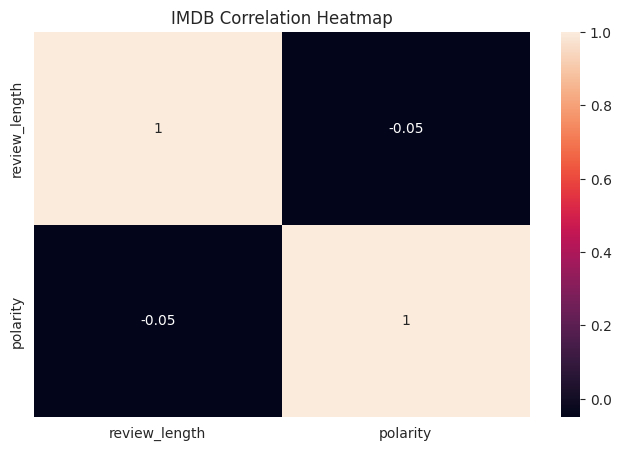

In [19]:
plt.figure()
sns.heatmap(imdb[['review_length','polarity']].corr(), annot=True)
plt.title("IMDB Correlation Heatmap")
plt.show()

Most common Bigrams

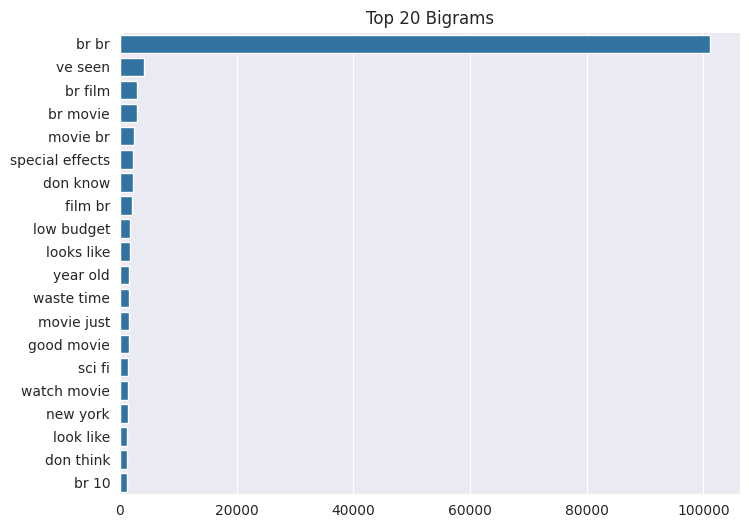

In [26]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=20)
X = vectorizer.fit_transform(imdb['review'].astype(str))

sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

bigram_words = [w[0] for w in words_freq]
bigram_counts = [w[1] for w in words_freq]

plt.figure(figsize=(8,6))
sns.barplot(x=bigram_counts, y=bigram_words)
plt.title("Top 20 Bigrams")
plt.show()


Outliers

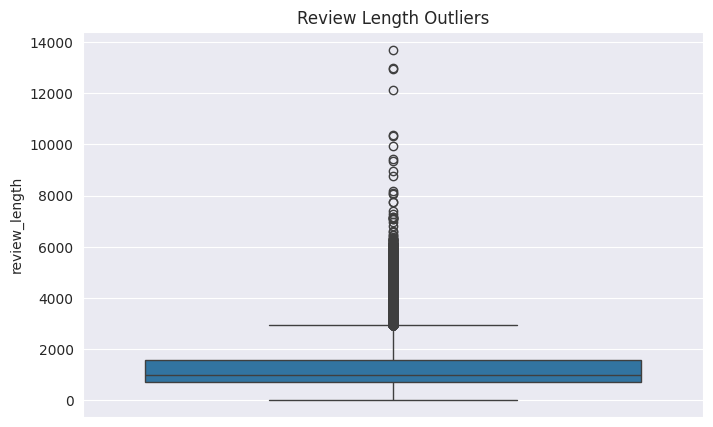

In [29]:
plt.figure()
sns.boxplot(y=imdb['review_length'])
plt.title("Review Length Outliers")
plt.show()

Sentence Level IMDB Data Analysis

In [34]:
imdb_sent_train = pd.read_csv('imdb_train_sentences.csv')
imdb_sent_test = pd.read_csv('imdb_test_sentences.csv')

imdb_sent = pd.concat([imdb_sent_train, imdb_sent_test], ignore_index=True)
imdb_sent.head()

,id,sentence,label
0,1,I really don't understand why people get so up...,1
1,1,"Remember folks, this is an SNL movie, not anyt...",1
2,1,"The Ladies Man is a hilarious movie, albeit st...",1
3,1,"Yes some of the jokes are stupid, and yes, the...",1
4,1,I really don't understand how anyone couldn't ...,1


In [41]:

# Safety fix for matplotlib $
import matplotlib
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['mathtext.default'] = 'regular'

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (8,5)

# -------------------------------
# Load Data (CHANGE PATH IF NEEDED)
# -------------------------------
imdb = pd.concat([imdb_sent_train, imdb_sent_test], ignore_index=True)  # change if needed

# Clean $ to avoid plotting crash
imdb['sentence'] = imdb['sentence'].astype(str).str.replace('$', '', regex=False)

# -------------------------------
# 1. Basic Info
# -------------------------------
print("Dataset Shape:", imdb.shape)
print("\nMissing Values:\n", imdb.isnull().sum())
print("\nLabel Distribution:\n", imdb['label'].value_counts())











Dataset Shape: (537072, 3)

Missing Values:
 id          0
sentence    0
label       0
dtype: int64

Label Distribution:
 label
0    275672
1    261400
Name: count, dtype: int64


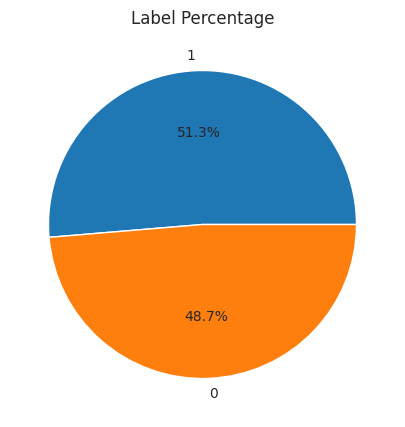

In [40]:

# -------------------------------
# 2. Class Distribution
# -------------------------------

plt.figure()
plt.pie(imdb['label'].value_counts(),
        labels=imdb['label'].unique(),
        autopct='%1.1f%%')
plt.title("Label Percentage")
plt.show()

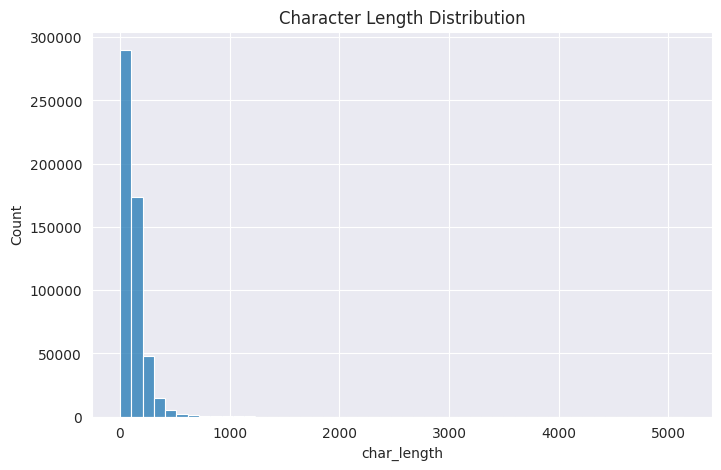

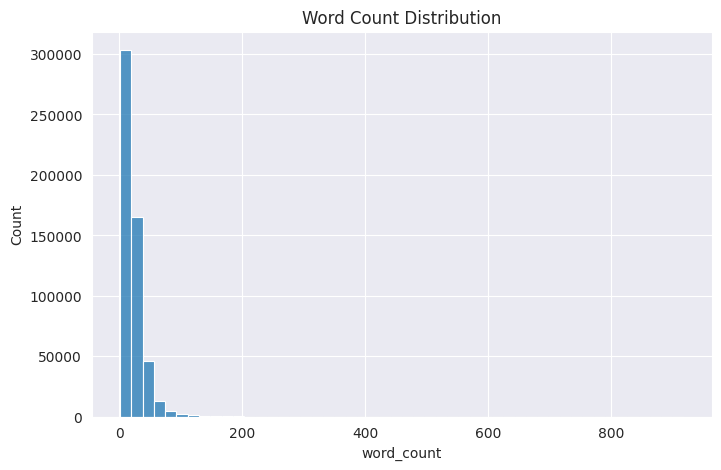

In [43]:
# -------------------------------
# 3. Sentence Length Analysis
# -------------------------------
imdb['char_length'] = imdb['sentence'].apply(len)
imdb['word_count'] = imdb['sentence'].apply(lambda x: len(x.split()))

plt.figure()
sns.histplot(imdb['char_length'], bins=50)
plt.title("Character Length Distribution")
plt.show()
print()
print()

plt.figure()
sns.histplot(imdb['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

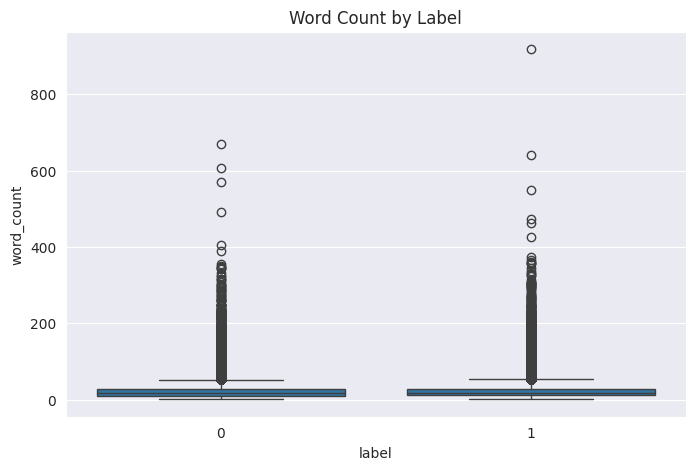

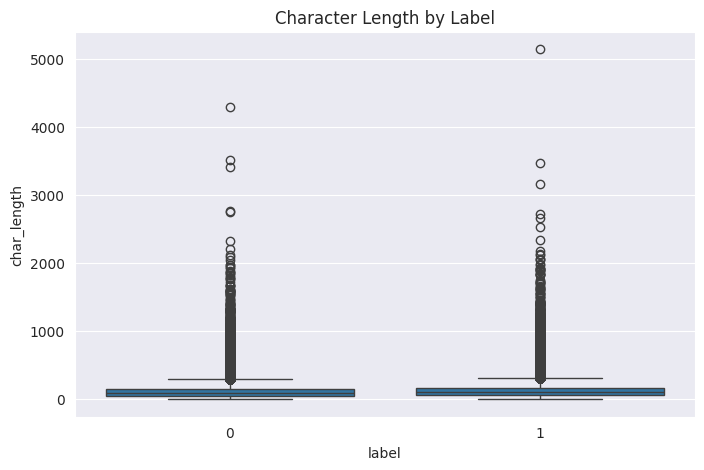

In [44]:
# -------------------------------
# 4. Length by Label
# -------------------------------
plt.figure()
sns.boxplot(x='label', y='word_count', data=imdb)
plt.title("Word Count by Label")
plt.show()


plt.figure()
sns.boxplot(x='label', y='char_length', data=imdb)
plt.title("Character Length by Label")
plt.show()

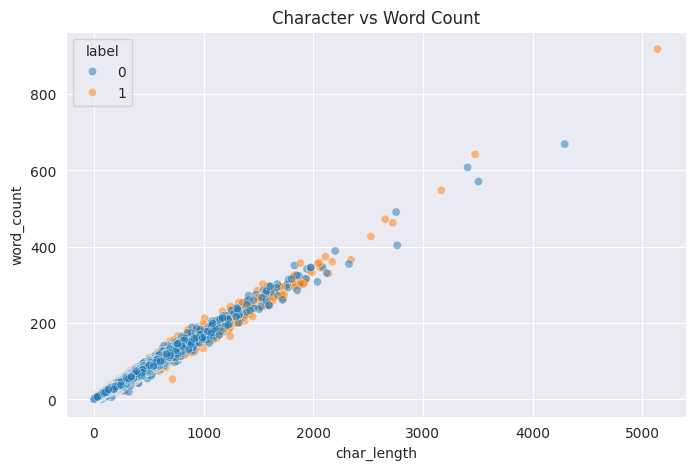

In [45]:
# -------------------------------
# 5. Scatter Plot
# -------------------------------
plt.figure()
sns.scatterplot(x='char_length', y='word_count', hue='label', data=imdb, alpha=0.5)
plt.title("Character vs Word Count")
plt.show()

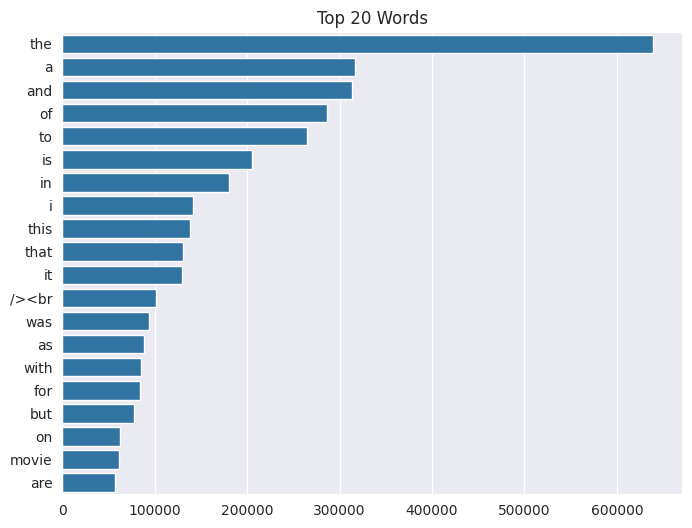

In [46]:
# -------------------------------
# 6. Top 20 Words
# -------------------------------
all_words = " ".join(imdb['sentence']).lower().split()
common = Counter(all_words).most_common(20)

words = [w[0] for w in common]
counts = [w[1] for w in common]

plt.figure(figsize=(8,6))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Words")
plt.show()

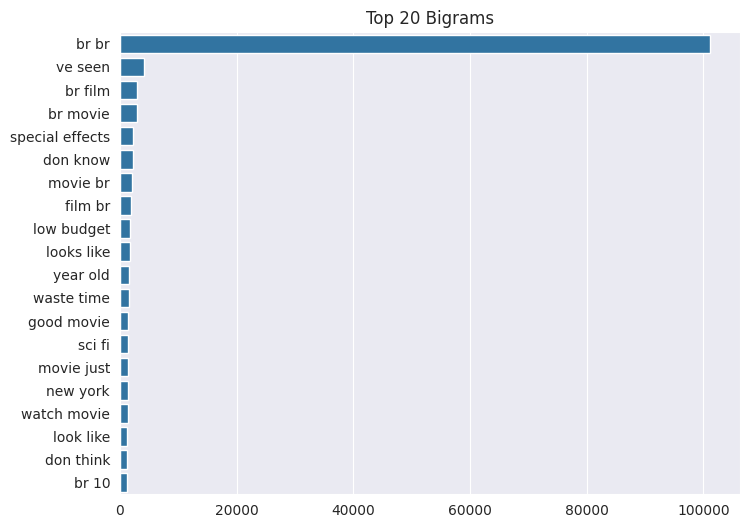

In [47]:
# -------------------------------
# 7. Top 20 Bigrams
# -------------------------------
vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english', max_features=20)
X = vectorizer.fit_transform(imdb['sentence'])

sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

bigram_words = [w[0] for w in words_freq]
bigram_counts = [w[1] for w in words_freq]

plt.figure(figsize=(8,6))
sns.barplot(x=bigram_counts, y=bigram_words)
plt.title("Top 20 Bigrams")
plt.show()

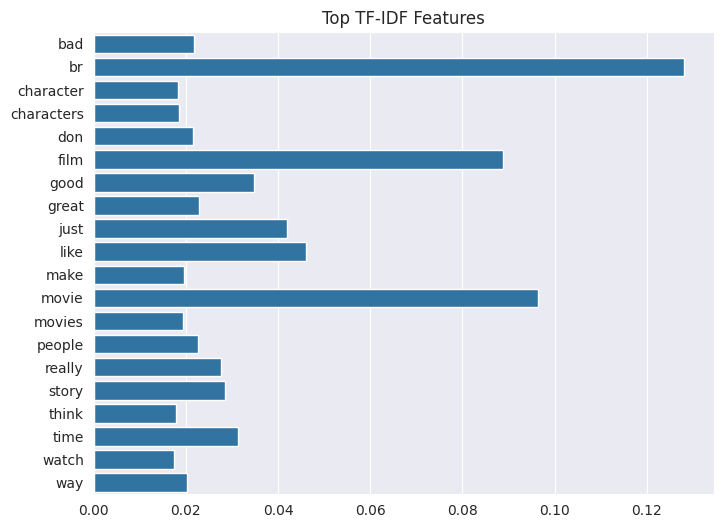

In [48]:
# -------------------------------
# 8. TF-IDF Important Words
# -------------------------------
tfidf = TfidfVectorizer(max_features=20, stop_words='english')
X_tfidf = tfidf.fit_transform(imdb['sentence'])

importance = np.asarray(X_tfidf.mean(axis=0)).ravel()
words = tfidf.get_feature_names_out()

plt.figure(figsize=(8,6))
sns.barplot(x=importance, y=words)
plt.title("Top TF-IDF Features")
plt.show()

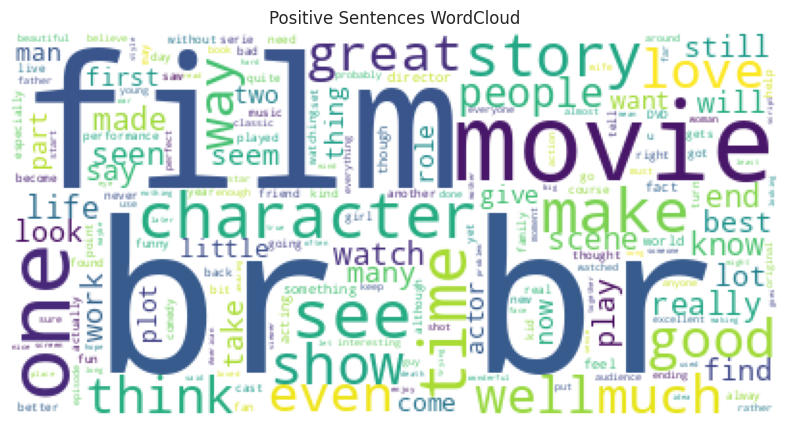

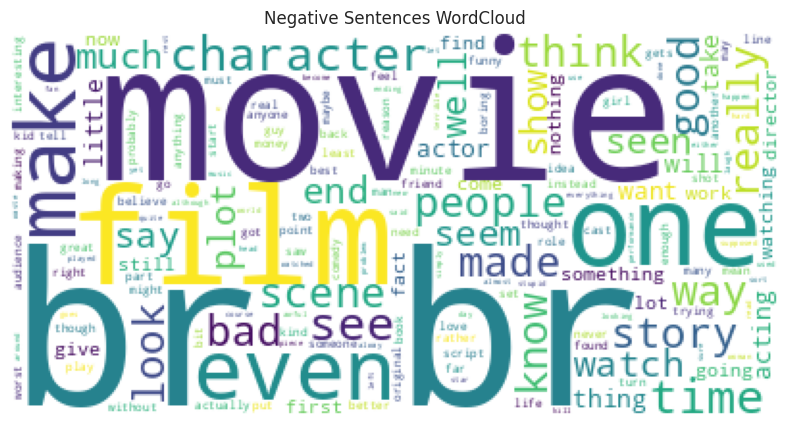

In [52]:
# -------------------------------
# 9. WordClouds
# -------------------------------
positive_text = " ".join(imdb[imdb['label']==1]['sentence'])
negative_text = " ".join(imdb[imdb['label']==0]['sentence'])

plt.figure(figsize=(10,5))
wc = WordCloud(background_color='white').generate(positive_text)
plt.imshow(wc)
plt.axis('off')
plt.title("Positive Sentences WordCloud")
plt.show()

print()

plt.figure(figsize=(10,5))
wc = WordCloud(background_color='white').generate(negative_text)
plt.imshow(wc)
plt.axis('off')
plt.title("Negative Sentences WordCloud")
plt.show()

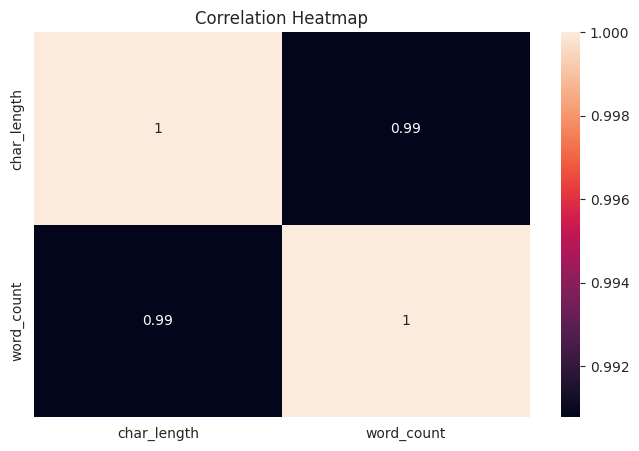

In [50]:
# -------------------------------
# 10. Correlation Heatmap
# -------------------------------
plt.figure()
sns.heatmap(imdb[['char_length','word_count']].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

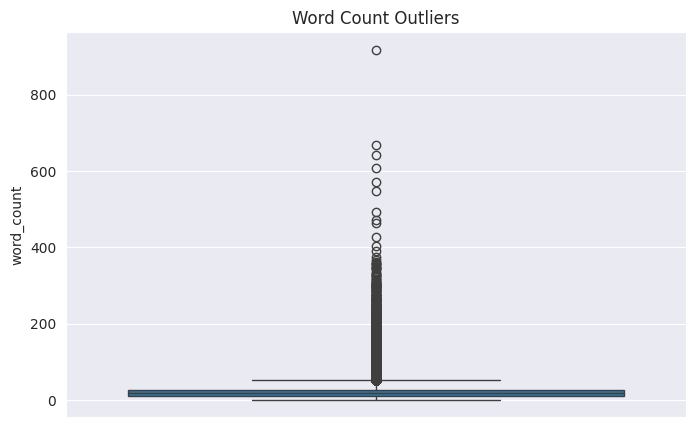

In [51]:
# -------------------------------
# 11. Outlier Detection
# -------------------------------
plt.figure()
sns.boxplot(y=imdb['word_count'])
plt.title("Word Count Outliers")
plt.show()